# Phase 1 — Data Audit & Realism Verification

**Goal:** make sure the data is trustworthy *before* doing any modeling.

If the data has structural issues, every analysis we do later will be wrong. So
we check the basics here, run a small set of sanity checks, and confirm we're
ready for Phase 2 before moving on.

---

### Design notes — the key choices behind this project

**Why we're framing this as a "cost-aware" problem instead of just predicting churn.**
A churn probability on its own doesn't tell the business what to do. The Retention
team has a fixed monthly budget and three different offers to choose from (each
with different costs and effectiveness). What they really need is *who to engage,
with which offer, to get the most return on the budget*. Framing it this way makes
expected ROI the top metric and forces us to care about how accurate the model's
probabilities are — not just how it ranks people.

**Why we focus on PR-AUC, not ROC-AUC.**
Only about 5.5% of subscribers churn in a given month. With such a small group of
actual churners, ROC-AUC can look better than it really is. PR-AUC focuses on how
well the model finds the small group of true churners, which is what the business
cares about.

**Why we care that the model's probabilities are accurate, not just ranked correctly.**
A model can rank users correctly from least to most likely to churn but still get
the *level* wrong. If it says "20% chance of churn" when the real rate is 35%,
our budget math will be off — we'll underspend and miss real churners. So we check
both how well it ranks (PR-AUC) and how close its probability numbers are to
reality (calibration).

**Why we keep the model and the decision rule as two separate pieces.**
The model's job is to give us a churn probability for each subscriber. The decision
rule's job is to use that probability — combined with how much each customer is
worth, how much each offer costs, and how much each offer helps — to pick the best
action. Keeping them separate means we can retrain the model anytime without redoing
the decision math, and we can change the budget without retraining the model.


In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_subscribers("../data/subscribers.csv")
print(f"Loaded {len(df):,} subscribers, {len(df.columns)} columns")
df.head()


Loaded 50,000 subscribers, 28 columns


,subscriber_id,tenure_months,plan_tier,billing_cycle,country,payment_method,auto_renew,multi_profile,engagement_cohort,watch_hours_last_7d,...,support_tickets_30d,support_tickets_90d,payment_failures_30d,payment_failures_90d,payment_failures_180d,days_since_plan_change,promo_active,days_until_promo_expires,monthly_revenue,churned_next_30d
0,2000000,3,Standard,monthly,Other,gift_card,True,False,regular,3.22,...,0,0,0,0,0,-1,False,-1,14.0,0
1,2000001,9,Standard,monthly,US,gift_card,True,True,heavy,9.39,...,0,1,0,1,1,-1,False,-1,14.0,0
2,2000002,12,Premium,monthly,UK,credit_card,False,False,regular,5.60,...,0,0,0,0,0,67,False,-1,19.0,0
3,2000003,6,Standard,monthly,US,credit_card,True,True,casual,0.67,...,0,0,0,0,0,177,False,-1,14.0,0
4,2000004,3,Basic,annual,UK,paypal,True,False,regular,1.51,...,0,0,0,0,0,-1,True,75,9.0,0


## A. Schema Integrity

First, the basics: are there missing values? Duplicate subscriber IDs?

> **Why we check the basics first.** Any analysis we do later is meaningless if
> the data has missing values or duplicate users. Missing values would quietly
> break our totals; duplicates would inflate our counts. We catch these now so
> the rest of the audit can trust the data.


In [14]:
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns)}")
# print(f"Memory:  {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

null_counts = df.isnull().sum()
nulls = null_counts[null_counts > 0]
print(f"\nNulls: {len(nulls)} columns affected  {'PASS' if len(nulls) == 0 else 'FAIL'}")

dup_ids = df["subscriber_id"].duplicated().sum()
print(f"Duplicate subscriber IDs: {dup_ids}  {'PASS' if dup_ids == 0 else 'FAIL'}")


Rows:    50,000
Columns: 28

Nulls: 0 columns affected  PASS
Duplicate subscriber IDs: 0  PASS


## B. Distribution Profiles

Quick check that the key columns have realistic ranges and shapes. First as a
table, then as a visual grid.

> **What to look for.** Engagement numbers usually have a few heavy users and a
> long tail of light users — that's normal. If we see two distinct "humps" in
> watch hours, that's the binge-watchers vs. casual users split. If revenue only
> takes three values (the three plan tiers), that's a sign to treat it as a
> category, not a continuous number.


In [3]:
for col in ["tenure_months", "watch_hours_last_30d", "logins_last_30d",
            "support_tickets_90d", "payment_failures_180d",
            "days_since_last_login", "monthly_revenue"]:
    s = df[col]
    print(f"{col:<25}  mean={s.mean():>7.2f}  std={s.std():>6.2f}  "
          f"min={s.min():>5.0f}  p50={s.median():>5.1f}  max={s.max():>5.0f}")


tenure_months              mean=   9.41  std=  9.78  min=    0  p50=  6.0  max=   60
watch_hours_last_30d       mean=  15.38  std= 15.48  min=    0  p50= 11.0  max=  205
logins_last_30d            mean=  13.20  std=  7.70  min=    0  p50= 13.0  max=   47
support_tickets_90d        mean=   0.23  std=  0.48  min=    0  p50=  0.0  max=    5
payment_failures_180d      mean=   0.14  std=  0.38  min=    0  p50=  0.0  max=    4
days_since_last_login      mean=   5.41  std=  7.22  min=    0  p50=  3.0  max=   53
monthly_revenue            mean=  13.01  std=  3.73  min=    9  p50= 14.0  max=   19


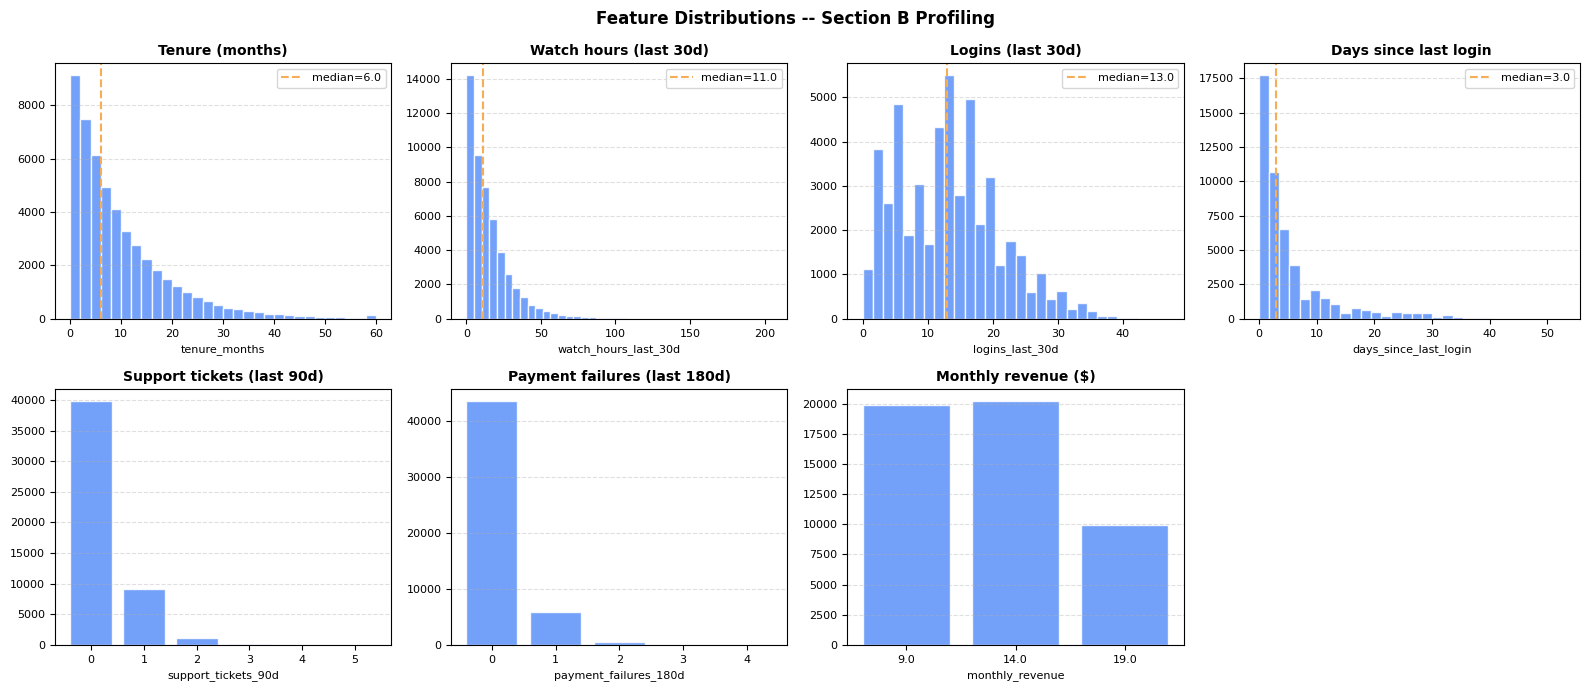

In [4]:
profile_cols = [
    ("tenure_months",        "hist", 30, "Tenure (months)"),
    ("watch_hours_last_30d", "hist", 40, "Watch hours (last 30d)"),
    ("logins_last_30d",      "hist", 30, "Logins (last 30d)"),
    ("days_since_last_login","hist", 30, "Days since last login"),
    ("support_tickets_90d",  "bar",  None, "Support tickets (last 90d)"),
    ("payment_failures_180d","bar",  None, "Payment failures (last 180d)"),
    ("monthly_revenue",      "bar",  None, "Monthly revenue ($)"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, (col, kind, bins, title) in zip(axes, profile_cols):
    s = df[col]
    if kind == "hist":
        ax.hist(s, bins=bins, color="#5B8FF9", edgecolor="white", alpha=0.85)
        ax.axvline(s.median(), color="#F6AD55", linestyle="--",
                   linewidth=1.5, label=f"median={s.median():.1f}")
        ax.legend(fontsize=8)
    else:
        vc = s.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values,
               color="#5B8FF9", edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(labelsize=8)
axes[-1].set_visible(False)
plt.suptitle("Feature Distributions -- Section B Profiling",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_feature_distributions.png", dpi=140, bbox_inches="tight")
plt.show()


## C. Nested-Window Check

For event-count features (tickets, payment failures), the count in a shorter
window must always be at most the count in a longer window.

> **Why the windows have to "nest" correctly.** If a subscriber had 3 support
> tickets in the last 90 days, they can't have had 4 in the last 7 days —
> that's impossible. The shorter window must always count ≤ the longer window.
> We check this to make sure later features like "what fraction of tickets are
> recent?" actually work.


In [5]:
checks = [
    ("support_tickets",  "support_tickets_7d",   "support_tickets_30d",  "support_tickets_90d"),
    ("payment_failures", "payment_failures_30d", "payment_failures_90d", "payment_failures_180d"),
]
for label, c_short, c_mid, c_long in checks:
    bad_1 = (df[c_short] > df[c_mid]).sum()
    bad_2 = (df[c_mid] > df[c_long]).sum()
    status = "PASS" if (bad_1 == 0 and bad_2 == 0) else "FAIL"
    print(f"{label}:  {c_short} <= {c_mid} <= {c_long}   "
          f"violations: {bad_1}, {bad_2}   {status}")

print("\nWatch-hour windows (medians only -- 7d is per-week so smaller):")
print(f"  7d  = {df['watch_hours_last_7d'].median():.2f}")
print(f"  30d = {df['watch_hours_last_30d'].median():.2f}")
print(f"  90d = {df['watch_hours_last_90d'].median():.2f}")


support_tickets:  support_tickets_7d <= support_tickets_30d <= support_tickets_90d   violations: 0, 0   PASS
payment_failures:  payment_failures_30d <= payment_failures_90d <= payment_failures_180d   violations: 0, 0   PASS

Watch-hour windows (medians only -- 7d is per-week so smaller):
  7d  = 2.46
  30d = 11.00
  90d = 11.10


## D. Are There Different "Types" of Users?

Real streaming services have at least three kinds of users: binge-watchers (heavy),
weekly regulars, and casuals who barely use it. We need each group represented in
roughly the right share.

**Targets:**
- Heavy users (more than 30 hrs/month): around 10–15%
- Casual users (less than 3 hrs/month): around 15–30%

> **Why having different user types matters.** If we modeled everyone as the same
> "average user," we'd miss huge differences in how they respond to retention
> offers. A curated playlist might bring a casual user back, while a heavy user
> would only respond to a free upgrade. Having distinct user types in the data
> lets the model learn these patterns.


In [6]:
cohort_share = df["engagement_cohort"].value_counts(normalize=True).round(3)
print("Cohort share:")
print(cohort_share)

heavy_real = (df["watch_hours_last_30d"] > 30).mean()
casual_real = (df["watch_hours_last_30d"] < 3).mean()
print(f"\nHeavy users (>30 hrs/mo):  {heavy_real:.1%}  (target: 10-15%)  "
      f"{'PASS' if 0.10 <= heavy_real <= 0.15 else 'FAIL'}")
print(f"Casual users (<3 hrs/mo):  {casual_real:.1%}  (target: 15-30%)  "
      f"{'PASS' if 0.15 <= casual_real <= 0.30 else 'FAIL'}")


Cohort share:
engagement_cohort
regular    0.602
casual     0.248
heavy      0.150
Name: proportion, dtype: float64

Heavy users (>30 hrs/mo):  13.1%  (target: 10-15%)  PASS
Casual users (<3 hrs/mo):  16.8%  (target: 15-30%)  PASS


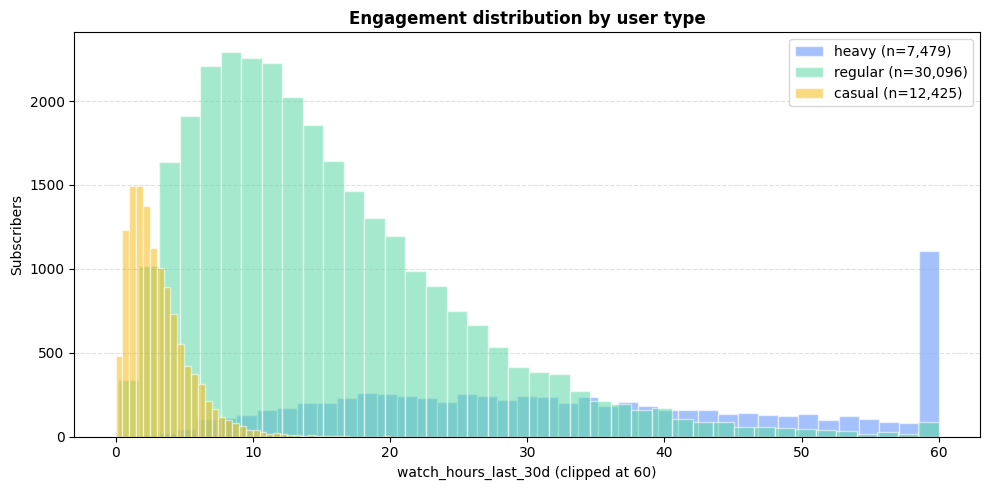

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"heavy": "#5B8FF9", "regular": "#5AD8A6", "casual": "#F6BD16"}
for cohort, color in colors.items():
    vals = df.loc[df["engagement_cohort"] == cohort, "watch_hours_last_30d"]
    ax.hist(vals.clip(upper=60), bins=40, alpha=0.55,
            label=f"{cohort} (n={len(vals):,})", color=color, edgecolor="white")
ax.set_xlabel("watch_hours_last_30d (clipped at 60)")
ax.set_ylabel("Subscribers")
ax.set_title("Engagement distribution by user type", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_engagement_by_cohort.png", dpi=140, bbox_inches="tight")
plt.show()


## E. Tenure Spikes — Month 2 and Month 12

The PM brief calls out two known spike points:
- **Month 2:** when free-trial users hit their second full bill
- **Month 12:** the one-year anniversary, when many people review what they subscribe to

Both should show as visibly elevated churn rates.

> **Why month 2 and month 12 matter.** Two months in is when free-trial users hit
> their second full bill and decide if it's worth keeping. Twelve months in is
> when many people review what they're subscribed to. Hulu, Netflix, and most
> subscription services see clear spikes at both points. If our model doesn't
> pick these up, it'll underestimate churn for exactly the moments the Retention
> team needs to act on.


In [8]:
tenure_curve = (
    df.groupby("tenure_months")["churned_next_30d"]
      .agg(["mean", "count"])
      .reset_index()
)
print("Churn rate by tenure month (selected):")
for m in [0, 1, 2, 3, 4, 6, 10, 11, 12, 13, 18, 24, 36]:
    row = tenure_curve[tenure_curve["tenure_months"] == m]
    if not row.empty:
        rate = row["mean"].iloc[0]
        n = row["count"].iloc[0]
        flag = " <-- expected spike" if m in (2, 11, 12) else ""
        print(f"  m={m:>2}  rate={rate:.2%}  n={n:>5,}{flag}")


Churn rate by tenure month (selected):
  m= 0  rate=6.22%  n=4,808
  m= 1  rate=6.62%  n=4,307
  m= 2  rate=9.47%  n=4,003 <-- expected spike
  m= 3  rate=5.68%  n=3,485
  m= 4  rate=5.88%  n=3,212
  m= 6  rate=5.86%  n=2,559
  m=10  rate=3.93%  n=1,706
  m=11  rate=6.05%  n=1,587 <-- expected spike
  m=12  rate=6.96%  n=1,466 <-- expected spike
  m=13  rate=4.24%  n=1,296
  m=18  rate=2.75%  n=  763
  m=24  rate=2.71%  n=  442
  m=36  rate=1.43%  n=  140


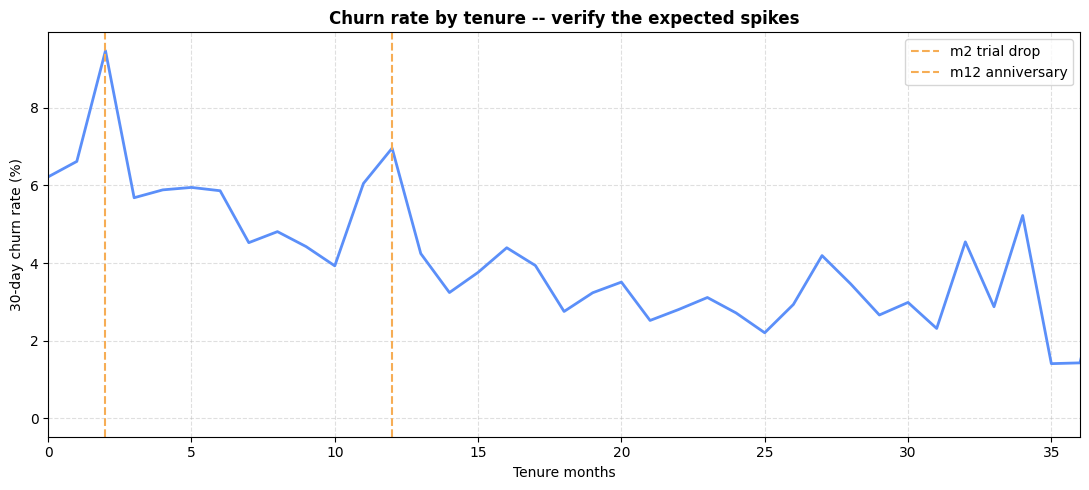

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tenure_curve["tenure_months"], tenure_curve["mean"] * 100,
        color="#5B8FF9", linewidth=2)
ax.axvline(2, color="#F6AD55", linestyle="--", linewidth=1.5, label="m2 trial drop")
ax.axvline(12, color="#F6AD55", linestyle="--", linewidth=1.5, label="m12 anniversary")
ax.set_xlabel("Tenure months")
ax.set_ylabel("30-day churn rate (%)")
ax.set_title("Churn rate by tenure -- verify the expected spikes", fontweight="bold")
ax.set_xlim(0, 36)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_tenure_churn_curve.png", dpi=140, bbox_inches="tight")
plt.show()


## F. Which Features Predict Churn on Their Own?

Quick scan of how much each feature relates to churn by itself. We're looking for:
- At least 2–3 features in the STRONG band (|correlation| > 0.10)
- A spread of moderate signal across multiple feature types
- No surprise zero-signal features that *should* have predictive power

> **Why most features look "weak" on their own.** Real workplace churn data looks
> the same way: no single feature gives the answer. That's exactly why we need a
> model — to combine many small signals into one prediction. A model like XGBoost
> handles this naturally by splitting on combinations of features.
>
> **Two features stand out as strong on their own:** `days_since_last_login`
> (when they last touched the app) and `logins_last_30d` (how often they touched
> it). They tell complementary stories — both *when* and *how often* matter, and
> neither alone is enough.
>
> **Why tickets and payment failures look weak.** Most subscribers have zero of
> either. The signal lives in the small group of users who *do* have them. A
> model handles this by treating "has any" as one signal and "how many" as another.


In [10]:
numeric_cols = [
    "tenure_months", "monthly_revenue",
    "watch_hours_last_7d", "watch_hours_last_30d", "watch_hours_last_90d",
    "distinct_titles_7d", "distinct_titles_30d", "distinct_titles_90d",
    "days_since_last_login", "logins_last_30d",
    "support_tickets_7d", "support_tickets_30d", "support_tickets_90d",
    "payment_failures_30d", "payment_failures_90d", "payment_failures_180d",
    "days_since_plan_change", "days_until_promo_expires",
]
bool_cols = ["auto_renew", "multi_profile", "promo_active"]

corrs = []
for col in numeric_cols:
    corrs.append((col, df[col].corr(df["churned_next_30d"])))
for col in bool_cols:
    corrs.append((col, df[col].astype(int).corr(df["churned_next_30d"])))

corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print("(>= 0.10 = STRONG, 0.05-0.10 = moderate, < 0.05 = weak)\n")
for col, corr in corrs:
    flag = "STRONG" if abs(corr) > 0.10 else (
           "moderate" if abs(corr) > 0.05 else "weak")
    print(f"  {col:<26}  corr = {corr:+.3f}  {flag}")


(>= 0.10 = STRONG, 0.05-0.10 = moderate, < 0.05 = weak)

  days_since_last_login       corr = +0.112  STRONG
  logins_last_30d             corr = -0.107  STRONG
  watch_hours_last_7d         corr = -0.087  moderate
  auto_renew                  corr = -0.085  moderate
  watch_hours_last_30d        corr = -0.084  moderate
  distinct_titles_30d         corr = -0.083  moderate
  distinct_titles_7d          corr = -0.079  moderate
  watch_hours_last_90d        corr = -0.075  moderate
  distinct_titles_90d         corr = -0.073  moderate
  tenure_months               corr = -0.060  moderate
  payment_failures_90d        corr = +0.044  weak
  multi_profile               corr = -0.043  weak
  payment_failures_180d       corr = +0.042  weak
  payment_failures_30d        corr = +0.040  weak
  monthly_revenue             corr = -0.037  weak
  support_tickets_7d          corr = +0.013  weak
  support_tickets_90d         corr = +0.013  weak
  support_tickets_30d         corr = +0.010  weak
  promo

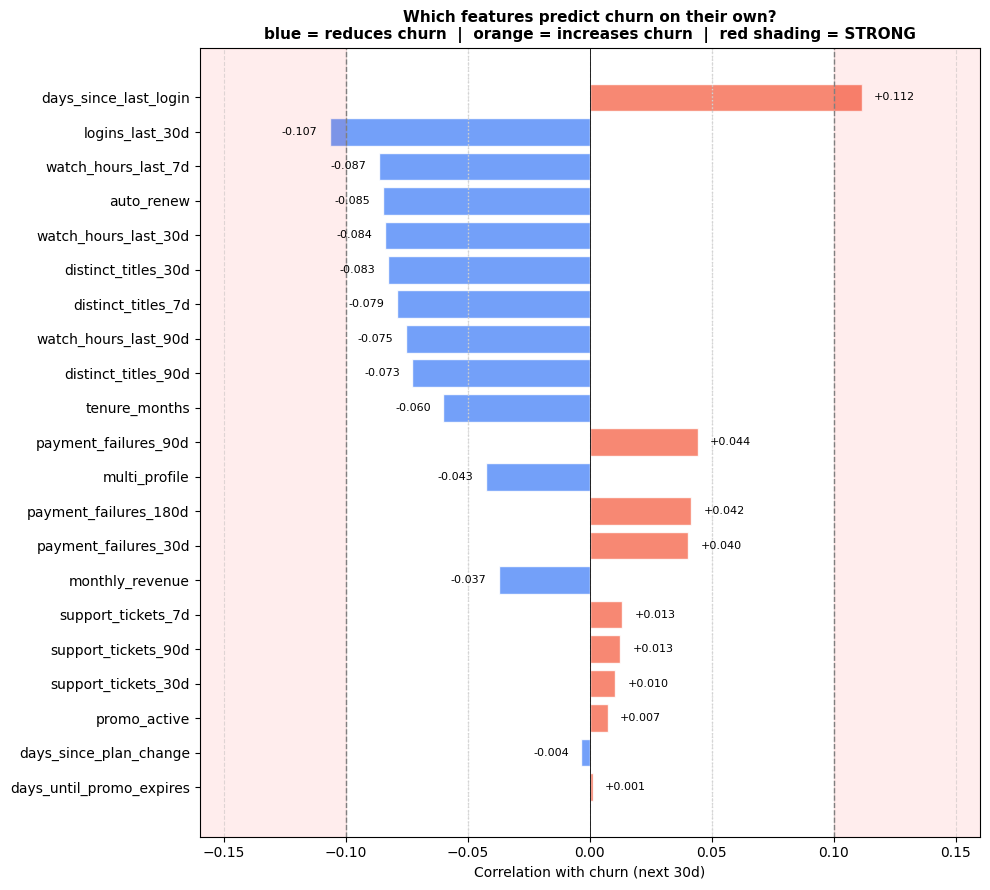

In [11]:
# Same correlations as a sorted bar chart.
# Blue bars = features that REDUCE churn risk.
# Orange bars = features that INCREASE churn risk.
# Red shading = STRONG signal (|correlation| > 0.10).

corr_df = pd.DataFrame(corrs, columns=["feature", "corr"])
corr_df["abs_corr"] = corr_df["corr"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ["#5B8FF9" if c < 0 else "#F6735B" for c in corr_df["corr"]]
ax.barh(corr_df["feature"], corr_df["corr"], color=colors_bar,
        alpha=0.85, edgecolor="white")
ax.axvspan(-1, -0.10, alpha=0.07, color="red")
ax.axvspan(0.10, 1, alpha=0.07, color="red")
for x in [-0.10, 0.10]:
    ax.axvline(x, color="gray", linestyle="--", linewidth=1)
for x in [-0.05, 0.05]:
    ax.axvline(x, color="lightgray", linestyle=":", linewidth=1)
ax.axvline(0, color="black", linewidth=0.6)
for y, (feat, c) in enumerate(zip(corr_df["feature"], corr_df["corr"])):
    offset = 0.005 if c >= 0 else -0.005
    ha = "left" if c >= 0 else "right"
    ax.text(c + offset, y, f"{c:+.3f}", va="center", ha=ha, fontsize=8)
ax.set_xlabel("Correlation with churn (next 30d)")
ax.set_title("Which features predict churn on their own?\n"
             "blue = reduces churn  |  orange = increases churn  |  red shading = STRONG",
             fontweight="bold", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlim(-0.16, 0.16)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_univariate_correlations.png", dpi=140, bbox_inches="tight")
plt.show()


## G. Final Verdict — Are We Ready for Phase 2?

All checks must PASS before we move on.

> **What "ready for Phase 2" really means.** The data is clean, the numbers look
> like real subscription data, and there's enough signal to actually train a
> model. Phase 2 will dig into richer patterns — retention curves, how segments
> behave, engagement trends over time.
>
> **What this audit does NOT catch.**
> - Whether the data captures users over time — we only see a snapshot here
> - Whether user behavior has been shifting recently (we'd need multiple snapshots)
> - Highly correlated features that confuse some models — we handle that in Phase 3
> - Accidentally using future information to predict the past — impossible by
>   design in our synthetic data, but the first thing to check in real-world data


In [12]:
dup_ids = df["subscriber_id"].duplicated().sum()
nulls_total = df.isnull().sum().sum()
heavy_real = (df["watch_hours_last_30d"] > 30).mean()
casual_real = (df["watch_hours_last_30d"] < 3).mean()
churn_rate = df["churned_next_30d"].mean()
m2_rate = tenure_curve.loc[tenure_curve["tenure_months"] == 2, "mean"].iloc[0]
m6_rate = tenure_curve.loc[tenure_curve["tenure_months"] == 6, "mean"].iloc[0]
nested_ok = (
    (df["support_tickets_7d"] <= df["support_tickets_30d"]).all() and
    (df["support_tickets_30d"] <= df["support_tickets_90d"]).all() and
    (df["payment_failures_30d"] <= df["payment_failures_90d"]).all() and
    (df["payment_failures_90d"] <= df["payment_failures_180d"]).all()
)
checks = [
    ("No nulls", nulls_total == 0),
    ("No duplicate IDs", dup_ids == 0),
    ("Nested counts hold", nested_ok),
    ("Heavy share 10-15%", 0.10 <= heavy_real <= 0.15),
    ("Casual share 15-30%", 0.15 <= casual_real <= 0.30),
    ("Churn rate 4-8%", 0.04 <= churn_rate <= 0.08),
    ("m2 spike visible", m2_rate > m6_rate),
]
for label, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {label}")

if all(ok for _, ok in checks):
    print("\nAll 7 checks pass. Data looks good. Ready for Phase 2.")
else:
    print("\nOne or more checks failed. Investigate before proceeding.")


  [PASS]  No nulls
  [PASS]  No duplicate IDs
  [PASS]  Nested counts hold
  [PASS]  Heavy share 10-15%
  [PASS]  Casual share 15-30%
  [PASS]  Churn rate 4-8%
  [PASS]  m2 spike visible

All 7 checks pass. Data looks good. Ready for Phase 2.


---

## 📝 What I'd do differently with real workplace data

1. **Add a freshness check.** Real data goes stale when data pipelines break. I'd
   compare today's row count to yesterday's and alert if it dropped more than 5%.

2. **Hold out the most recent month of data.** A single snapshot can hide whether
   user behavior has been shifting. Reserving the latest data lets us catch
   surprises before they hit production.

3. **Weight the audit checks by user tenure.** Long-tenured users dominate the
   count but rarely churn — they could be masking problems specific to new/short-
   tenure users where most of the action lives.

4. **Turn this notebook into a daily dashboard.** Right now this is a one-time
   audit. A nightly version would catch schema changes or weird distribution
   shifts before they break the model.

## 🔭 Next: Phase 2

With the data validated, Phase 2 will cover:
- How churn rates differ across each segment (plan, billing, country, etc.)
- Survival curves — how long subscribers stick around, by plan tier and billing
- Whether engagement trends (declining watch time) really predict churn
- A combined view of tenure × user type to find the highest-risk groups
